In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [34]:
df.tail()

,Unnamed: 0,TV,radio,newspaper,sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [35]:
df.drop(['Unnamed: 0'], axis=1)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [36]:
df.shape

(200, 5)

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

In [38]:
Xs = df.drop(['sales', 'Unnamed: 0'], axis=1)
y = df['sales'].values.reshape(-1,1)
x_train, x_test, y_train, y_test = train_test_split(Xs,y,test_size = 0.3) 
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
reg = LinearRegression()
reg.fit(x_train, y_train)

(140, 3)
(60, 3)
(140, 1)
(60, 1)


LinearRegression()

In [39]:
print("Slope: ",reg.coef_)
print("Intercept: ",reg.intercept_)

Slope:  [[ 0.04651898  0.19271897 -0.00415099]]
Intercept:  [2.68906045]


In [40]:
print("The linear model is: Y = {:.5} + {:.5}*TV + {:.5}*radio + {:.5}*newspaper".format(reg.intercept_[0], reg.coef_[0][0], reg.coef_[0][1], reg.coef_[0][2]))

The linear model is: Y = 2.6891 + 0.046519*TV + 0.19272*radio + -0.004151*newspaper


In [41]:
y_pred = reg.predict(x_test)
print(y_pred)

[[22.8465111 ]
 [20.42806169]
 [18.65692438]
 [18.33309307]
 [14.93098623]
 [12.70904252]
 [20.35814234]
 [ 8.51064996]
 [11.35738184]
 [ 7.17417131]
 [ 7.68742073]
 [ 8.2577025 ]
 [ 7.93948886]
 [ 6.27864088]
 [17.35625468]
 [12.423234  ]
 [15.31906775]
 [18.15221266]
 [19.84337959]
 [10.67832191]
 [ 8.88744356]
 [ 9.85495363]
 [21.09479862]
 [ 9.19472478]
 [12.43735758]
 [20.83571776]
 [ 8.66354071]
 [14.29917749]
 [ 7.38001627]
 [23.17954776]
 [17.03432425]
 [ 5.12186205]
 [ 9.73454328]
 [19.02741971]
 [ 7.40391685]
 [18.13721531]
 [ 5.79373168]
 [18.98677752]
 [ 6.16145333]
 [ 9.84227849]
 [ 7.5953116 ]
 [ 9.6771888 ]
 [ 6.85588912]
 [13.37043228]
 [14.23528509]
 [ 9.96922757]
 [19.74372622]
 [13.90100212]
 [20.39060652]
 [15.22900294]
 [ 6.58246503]
 [19.28198585]
 [17.58130963]
 [ 8.88616278]
 [17.01831967]
 [13.50708254]
 [21.12183144]
 [17.28533719]
 [ 9.32622837]
 [16.31261919]]


In [42]:
def myfunc(TV,radio,newspaper):
  Y = 2.877 + 0.046565*TV + 0.17916*radio + 0.0034505*newspaper
  return Y
predictedsales = myfunc(39.5,41.1,10.8)
print("Predicted Sales is ", predictedsales)

Predicted Sales is  12.117058900000002


In [43]:
def myfunc(TV,radio):
  Y = Y = 2.927 + 0.0466*TV + 0.1811*radio
  return Y
predictedsales = myfunc(39.5,41.1)
print("Predicted Sales is ", predictedsales)

Predicted Sales is  12.21091


In [44]:
from sklearn.metrics import mean_absolute_error 
predictions = reg.predict(x_test)
mae = mean_absolute_error(y_test,predictions)
print("Mean Absolute Error = ",mae)

Mean Absolute Error =  1.2406929838030123


In [45]:
from sklearn.metrics import mean_squared_error
predictions = reg.predict(x_test)
mse = mean_squared_error(y_test,predictions)
print("Mean Squared Error = ",mse)

Mean Squared Error =  2.1873558346819464


In [46]:
from sklearn.linear_model import LinearRegression
predictions = reg.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test,predictions))
print("Root Mean Squared Error = ",rmse)

Root Mean Squared Error =  1.4789712081991138


In [47]:
reg.score(Xs, y)

0.8961685593529167

/usr/local/lib/python3.6/dist-packages/seaborn/axisgrid.py:2076: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


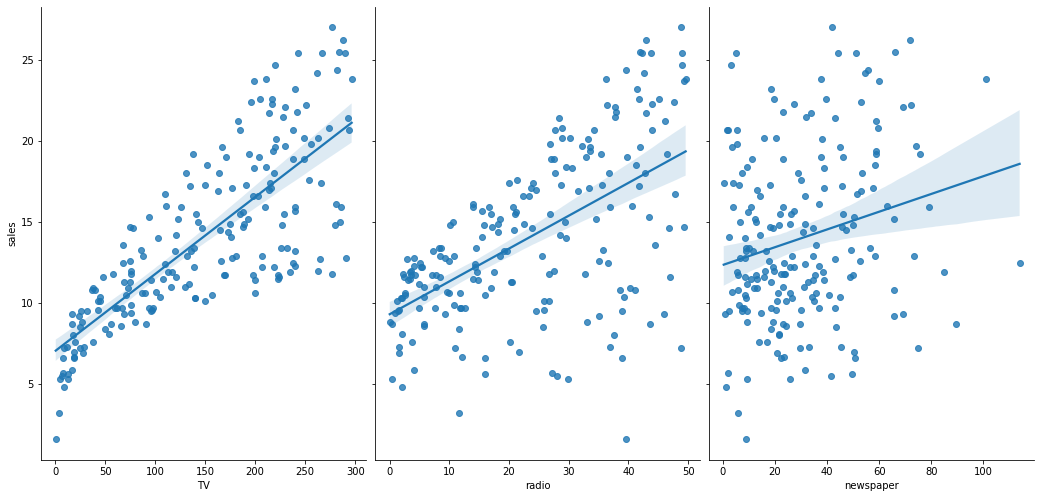

In [48]:
import seaborn as sns
%matplotlib inline
sns.pairplot(df, x_vars=['TV', 'radio', 'newspaper'], y_vars='sales', size=7, aspect=0.7, kind='reg')

In [49]:
feature_cols = ['TV', 'radio']
X = df[feature_cols]
Y = df.sales
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=1)
reg.fit(X_train, Y_train)

print("Slope: ",reg.coef_)
print("Intercept: ",reg.intercept_)

print("The linear model is: Y = 2.927 + 0.0466*TV + 0.1811*radio")
Y_pred = reg.predict(X_test)


Slope:  [0.04660234 0.18117959]
Intercept:  2.9272373202664816
The linear model is: Y = 2.927 + 0.0466*TV + 0.1811*radio


/usr/local/lib/python3.6/dist-packages/seaborn/axisgrid.py:2076: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


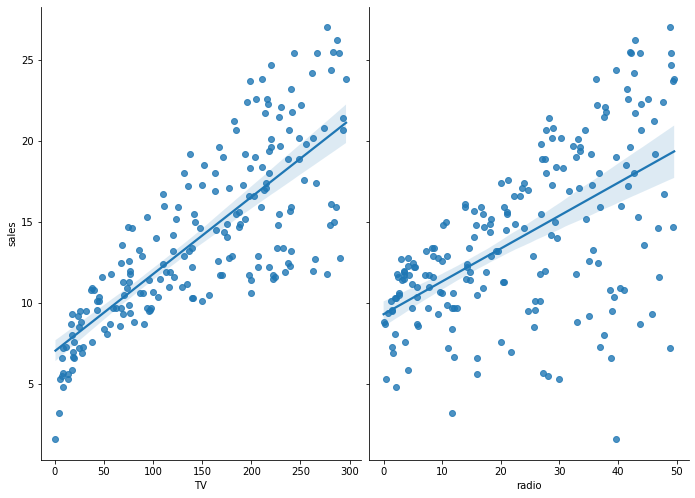

In [50]:
import seaborn as sns
%matplotlib inline
sns.pairplot(df, x_vars=['TV', 'radio'], y_vars='sales', size=7, aspect=0.7, kind='reg')

In [51]:
from sklearn.metrics import mean_absolute_error,  mean_squared_error
predictions = reg.predict(X_test)
mae = mean_absolute_error(Y_test,predictions)
print("Mean Absolute Error = ",mae)

Mean Absolute Error =  1.0477590411212605


In [52]:
predictions = reg.predict(X_test)
mae = mean_squared_error(Y_test,predictions)
print("Mean Absolute Error = ",mae)

Mean Absolute Error =  1.9262760418667433


In [53]:
rmse = np.sqrt(mean_squared_error(Y_test,Y_pred))
print("Root Mean Squared Error = ",rmse)

Root Mean Squared Error =  1.387903469938289


In [54]:
reg.score(X, y)

0.8966248862712952